# Import Data and Dependencies 

In [3]:
# import dependencies
import torch.nn as nn
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import tsfeatures as tsf
from sklearn.preprocessing import RobustScaler
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from dataset_preparation import split_data, create_sequences_np
import model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from helper_func import evaluate_model
import pickle

In [4]:
# import the sony stock csv file and parse the dates to datetime format compatible with pandas library
df = pd.read_csv('./sony_stock_data.csv', parse_dates=['Date'])
# set the Date column as the index (optional, but helpful)
df = df.set_index('Date')
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-01-02,3.203941,3.246884,3.189004,3.235681,13127000
2014-01-03,3.207675,3.222611,3.196472,3.213276,4642000
2014-01-06,3.230079,3.265554,3.224478,3.230079,11781500
2014-01-07,3.233814,3.245017,3.211409,3.241283,17191500
2014-01-08,3.407454,3.420523,3.222611,3.248750,42864500


In [5]:
# check for null values and imputations (if none, then no need to resample or drop)
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

# Feature Engineering and Feature Extraction

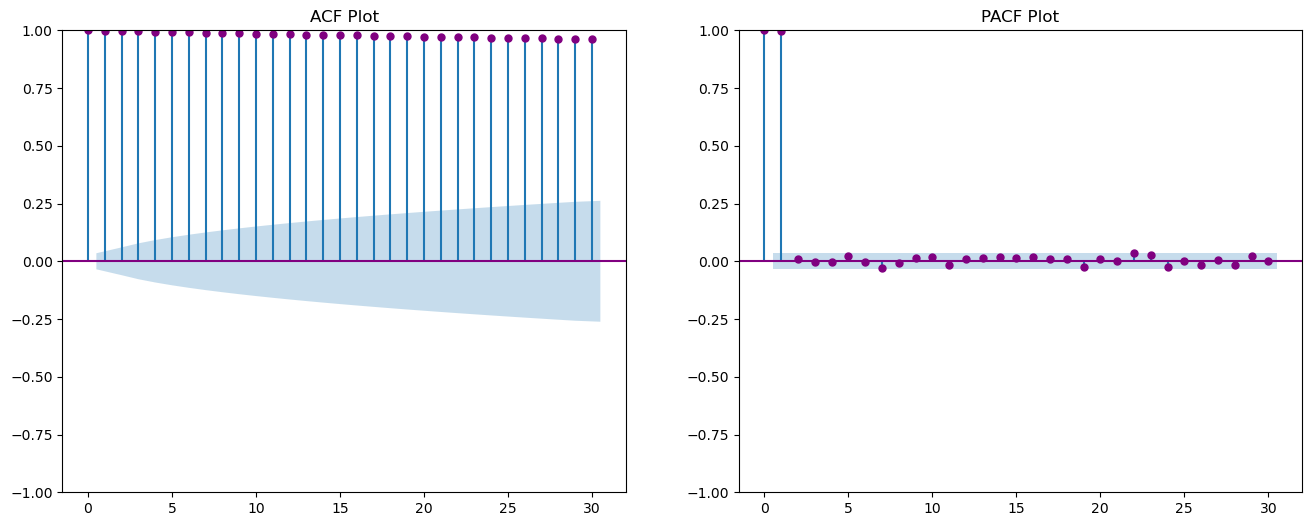

In [6]:
# Plot ACF and PACF to visualize the optimal lag
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF plot (autocorrelation)
plot_acf(df['Close'], ax=axes[0], lags=30, color='purple')
axes[0].set_title('ACF Plot')

# PACF plot (partial autocorrelation)
plot_pacf(df['Close'], ax=axes[1], lags=30, method='ywm', color='purple')
axes[1].set_title('PACF Plot')

plt.show()

In [7]:
# add a unique_id column to use tsf package methods (requires a unique_id column)
df['unique_id'] = 1
# rename the Closing prices column to y (the target, also required by the tsf package)
df = df.rename(columns={'Close': 'y'})

In [8]:
# extract autocorrelation coefficient statistics for further analysis
'''
x_acf1 - the first autocorrelation coefficient from the original data;
x_acf10 - the sum of squares of the first ten autocorrelation coefficients from the original data;
diff1_acf1 - the first autocorrelation coefficient from the differenced data;
diff1_acf10 - the sum of squares of the first ten autocorrelation coefficients from the differenced data;
diff2_acf1 - the first autocorrelation coefficient from the twice differenced data;
diff2_acf10 - the sum of squares of the first ten autocorrelation coefficients from the twice differenced data;
seas_acf1 - the autocorrelation coefficient at the first seasonal lag is also returned.

'''
acf_feat = tsf.tsfeatures(df, freq=4, features=[tsf.acf_features])
acf_feat.head()

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,1,0.998537,9.843315,-0.003971,0.005745,-0.510477,0.267023,0.994228


In [9]:
# statistical features extraction
summary_stats = tsf.tsfeatures(df, 
    freq=4, features=[tsf.statistics], scale=False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)

,unique_id,min,p25,median,p75,max
0,1,2.847324,6.216718,13.057427,19.004598,30.26


In [10]:
# calculate the rolling statistics within a 30 day window range - due to lack of seasonality patterns but a strong positive trend
# shift the rolling average by 1 day to avoid look-ahead bias (yesterday's rolling average)
data = df['y']
df['Rolling_Mean_30'] = data.rolling(window=30).mean().shift(1)

In [11]:
# extract date features (day of week, month, quarter)
df['Month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['quarter'] = df['Month'].apply(lambda month: (month - 1) // 4)

df.head()

,y,High,Low,Open,Volume,unique_id,Rolling_Mean_30,Month,day_of_week,quarter
Date,,,,,,,,,,
2014-01-02,3.203941,3.246884,3.189004,3.235681,13127000,1,NaN,1,3,0
2014-01-03,3.207675,3.222611,3.196472,3.213276,4642000,1,NaN,1,4,0
2014-01-06,3.230079,3.265554,3.224478,3.230079,11781500,1,NaN,1,0,0
2014-01-07,3.233814,3.245017,3.211409,3.241283,17191500,1,NaN,1,1,0
2014-01-08,3.407454,3.420523,3.222611,3.248750,42864500,1,NaN,1,2,0


In [12]:
# scale time based features cyclically using sine/cosine functions

# define the time periods
days = 7
month = 12
quarter = 4

# scale the days of the week
df['day_of_week_sin'] = np.sin((2 * np.pi * df['day_of_week']) / days)
df['day_of_week_cos'] = np.cos((2 * np.pi * df['day_of_week']) / days)

# scale the months in a year
df['month_sin'] = np.sin((2 * np.pi * df['Month']) / month)
df['month_cos'] = np.cos((2 * np.pi * df['Month']) / month)

# scale the yearly quarters
df['quarter_sin'] = np.sin((2 * np.pi * df['quarter']) / quarter)
df['quarter_cos'] = np.cos((2 * np.pi * df['quarter']) / quarter)

df.head()

,y,High,Low,Open,Volume,unique_id,Rolling_Mean_30,Month,day_of_week,quarter,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos
Date,,,,,,,,,,,,,,,,
2014-01-02,3.203941,3.246884,3.189004,3.235681,13127000,1,NaN,1,3,0,0.433884,-0.900969,0.5,0.866025,0.0,1.0
2014-01-03,3.207675,3.222611,3.196472,3.213276,4642000,1,NaN,1,4,0,-0.433884,-0.900969,0.5,0.866025,0.0,1.0
2014-01-06,3.230079,3.265554,3.224478,3.230079,11781500,1,NaN,1,0,0,0.000000,1.000000,0.5,0.866025,0.0,1.0
2014-01-07,3.233814,3.245017,3.211409,3.241283,17191500,1,NaN,1,1,0,0.781831,0.623490,0.5,0.866025,0.0,1.0
2014-01-08,3.407454,3.420523,3.222611,3.248750,42864500,1,NaN,1,2,0,0.974928,-0.222521,0.5,0.866025,0.0,1.0


In [13]:
# extract lag features at lag=[1,2,7] for close prices
df['lag_1_y'] = df['y'].shift(1)
df['lag_7_y'] = df['y'].shift(7)

# keep yesterdays trade volume
df["lag1_volume"] = df["Volume"].shift(1)

df.head()

,y,High,Low,Open,Volume,unique_id,Rolling_Mean_30,Month,day_of_week,quarter,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,lag_1_y,lag_7_y,lag1_volume
Date,,,,,,,,,,,,,,,,,,,
2014-01-02,3.203941,3.246884,3.189004,3.235681,13127000,1,NaN,1,3,0,0.433884,-0.900969,0.5,0.866025,0.0,1.0,NaN,NaN,NaN
2014-01-03,3.207675,3.222611,3.196472,3.213276,4642000,1,NaN,1,4,0,-0.433884,-0.900969,0.5,0.866025,0.0,1.0,3.203941,NaN,13127000.0
2014-01-06,3.230079,3.265554,3.224478,3.230079,11781500,1,NaN,1,0,0,0.000000,1.000000,0.5,0.866025,0.0,1.0,3.207675,NaN,4642000.0
2014-01-07,3.233814,3.245017,3.211409,3.241283,17191500,1,NaN,1,1,0,0.781831,0.623490,0.5,0.866025,0.0,1.0,3.230079,NaN,11781500.0
2014-01-08,3.407454,3.420523,3.222611,3.248750,42864500,1,NaN,1,2,0,0.974928,-0.222521,0.5,0.866025,0.0,1.0,3.233814,NaN,17191500.0


In [14]:
# extract the daily returns by a lag of 1, 2 and 7
df["daily_returns"] = df['y'].pct_change().shift(1)

# extract 30 day rolling volatility and shift by 1 day to avoid the model from foreseeing the future and disrupt accuracy metrics
df["volatility_30"] = df["y"].pct_change().rolling(window=30).std().shift(1)

# extract the high-low spread 
df["hl_spread"] = (df["High"] - df["Low"]).shift(1)

# extract the RSI values using a 14 day period (momentum indicator)
delta = df["y"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
df["rsi_14"] = (100 - (100 / (1 + rs))).shift(1)

df.tail()

,y,High,Low,Open,Volume,unique_id,Rolling_Mean_30,Month,day_of_week,quarter,...,month_cos,quarter_sin,quarter_cos,lag_1_y,lag_7_y,lag1_volume,daily_returns,volatility_30,hl_spread,rsi_14
Date,,,,,,,,,,,,,,,,,,,,,
2026-08-18,23.43,23.490000,23.299999,23.389999,3751400,1,22.154667,8,1,1,...,-0.5,1.0,6.123234e-17,23.700001,23.459999,4180900.0,-0.024290,0.019651,0.250000,58.918935
2026-08-19,23.49,23.870001,23.430000,23.490000,3854000,1,22.222333,8,2,1,...,-0.5,1.0,6.123234e-17,23.430000,23.820000,3751400.0,-0.011392,0.019795,0.190001,51.520912
2026-08-20,23.58,23.680000,23.500000,23.610001,3686000,1,22.300333,8,3,1,...,-0.5,1.0,6.123234e-17,23.490000,23.610001,3854000.0,0.002561,0.019595,0.440001,57.468876
2026-08-21,23.92,24.080000,23.740000,23.760000,3718400,1,22.388667,8,4,1,...,-0.5,1.0,6.123234e-17,23.580000,23.540001,3686000.0,0.003831,0.019414,0.180000,53.619908
2026-08-24,24.26,24.320000,24.100000,24.150000,3191700,1,22.491000,8,0,1,...,-0.5,1.0,6.123234e-17,23.920000,23.610001,3718400.0,0.014419,0.019441,0.340000,65.617455


In [15]:
# drop NaN rows
print(df.isna().sum())
data = df.copy()
data = data.dropna()
print(data.isna().sum())

y                   0
High                0
Low                 0
Open                0
Volume              0
unique_id           0
Rolling_Mean_30    30
Month               0
day_of_week         0
quarter             0
day_of_week_sin     0
day_of_week_cos     0
month_sin           0
month_cos           0
quarter_sin         0
quarter_cos         0
lag_1_y             1
lag_7_y             7
lag1_volume         1
daily_returns       2
volatility_30      31
hl_spread           1
rsi_14             15
dtype: int64
y                  0
High               0
Low                0
Open               0
Volume             0
unique_id          0
Rolling_Mean_30    0
Month              0
day_of_week        0
quarter            0
day_of_week_sin    0
day_of_week_cos    0
month_sin          0
month_cos          0
quarter_sin        0
quarter_cos        0
lag_1_y            0
lag_7_y            0
lag1_volume        0
daily_returns      0
volatility_30      0
hl_spread          0
rsi_14             

In [16]:
print('Number of rows before dropping: ', len(df))
print('Number of rows after dropping: ', len(data))

Number of rows before dropping:  3179
Number of rows after dropping:  3148


In [17]:
data.columns

Index(['y', 'High', 'Low', 'Open', 'Volume', 'unique_id', 'Rolling_Mean_30',
       'Month', 'day_of_week', 'quarter', 'day_of_week_sin', 'day_of_week_cos',
       'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'lag_1_y',
       'lag_7_y', 'lag1_volume', 'daily_returns', 'volatility_30', 'hl_spread',
       'rsi_14'],
      dtype='object')

In [18]:
# save the current state of this dataframe for comparing its performance with its stationary form
data.to_csv('./data.csv')

In [19]:
# drop the necessary columns 
columns = ['unique_id', 'day_of_week', 'quarter', 'Month', 'High', 'Low']

data = data.drop(columns=columns)
data.columns

Index(['y', 'Open', 'Volume', 'Rolling_Mean_30', 'day_of_week_sin',
       'day_of_week_cos', 'month_sin', 'month_cos', 'quarter_sin',
       'quarter_cos', 'lag_1_y', 'lag_7_y', 'lag1_volume', 'daily_returns',
       'volatility_30', 'hl_spread', 'rsi_14'],
      dtype='object')

# Splitting and Preparing the Dataset for Training

In [20]:
# split the dataset 
X_train, y_train, X_val, y_val, X_test, y_test = split_data(data)

Train size: 2204  |  Test size: 472 | Val size 472
Train period: 2014-02-18 to 2022-11-15
Test + val period : 2022-11-16 to 2026-08-24


In [21]:
# ensure that train and test sizes add up to the total number of rows 
assert len(X_test) + len(X_train) + len(X_val) == len(data), 'Error: test and train sizes are not equal to total number of rows in dataframe'

In [22]:
# scale columns using RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# scale the target value for more stable training
y_scaler = RobustScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
)

y_val_scaled =  y_scaler.transform(
    y_val.to_numpy().reshape(-1, 1)
)

In [23]:
# define sequence len (tunable hyperparameter)
seq_len = 30

X_val_ctx = np.concatenate([X_train_scaled[-seq_len:], X_val_scaled])
y_val_ctx = np.concatenate([y_train_scaled[-seq_len:], y_val_scaled])
X_val_seq, y_val_seq = create_sequences_np(X_val_ctx, y_val_ctx, seq_len)

X_test_ctx = np.concatenate([X_val_scaled[-seq_len:], X_test_scaled])
y_test_ctx = np.concatenate([y_val_scaled[-seq_len:], y_test_scaled])
X_test_seq, y_test_seq = create_sequences_np(X_test_ctx, y_test_ctx, seq_len)

# create sequences of len=30 series for train, test and val
X_train_seq, y_train_seq = create_sequences_np(X_train_scaled, y_train_scaled, seq_len)
X_test_seq, y_test_seq = create_sequences_np(X_test_ctx, y_test_ctx, seq_len)
X_val_seq, y_val_seq = create_sequences_np(X_val_ctx, y_val_ctx, seq_len)


In [24]:
# convert sequenced data to tensors 
sets = [X_train_seq, y_train_seq, X_test_seq, y_test_seq, X_val_seq, y_val_seq]

for i in range(0, len(sets)):
    sets[i] = torch.tensor(sets[i], dtype=torch.float32)

# output data tensor shapes (training examples, seq length, features)
print('x_train.shape = ',sets[0].shape)
print('y_train.shape = ', sets[1].shape)
print('x_test.shape = ', sets[2].shape)
print('y_test.shape = ',sets[3].shape)

x_train.shape =  torch.Size([2174, 30, 16])
y_train.shape =  torch.Size([2174, 1])
x_test.shape =  torch.Size([472, 30, 16])
y_test.shape =  torch.Size([472, 1])


# Initialize Model and Train using the data

In [25]:
# set torch manual seed
torch.manual_seed(1)

# initialize pytorch lightning data module
lstm_dm = model.SONYStocksDataModule(X_train=sets[0], y_train=sets[1],
                             X_test=sets[2], y_test=sets[3], batch_size=64, X_val=sets[4]
                              , y_val = sets[5])

In [24]:
# define differents models with different param configs
models = [model.RegressionLSTMTrainer(n_features=X_train.shape[-1]), 
          model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=64, n_layers=1), 
          model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=128, n_layers=1)]
         model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=64, n_layers=2), 
         model.RegressionLSTMTrainer(n_features=X_train.shape[-1], n_layers=2),
         model.RegressionLSTMTrainer(n_features=X_train.shape[-1], hidden_units=128, n_layers=2)]

In [ ]:
# initialize an arr to save each model checkpoint
checkpoints = []
trainers = []

for model in models:
    # define model checkpoint save the best validation result out of every epoch per model 
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)
    checkpoints.append(checkpoint)

    if torch.mps.is_available():
        trainer = pl.Trainer(max_epochs=200, accelerator='mps', devices=1, callbacks=[checkpoint], enable_progress_bar=False)
    elif torch.cuda.is_available():
        trainer = pl.Trainer(max_epochs=200, accelerator='cuda', devices=1, callbacks=[checkpoint])
    else:
        trainer = pl.Trainer(max_epochs=200, callbacks=[checkpoint])

        
    # fit the trainer to the dm for each of the configured models
    trainer.fit(model=model, datamodule=lstm_dm)
    trainers.append(trainer)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


# Model inference and baseline comparison

In [112]:
# evaluate on best lstm model based on params for each complete model

best_model_index = -1
current_r2 = 1

for m, ckpt in zip(models, checkpoints):
    # return predictions
    y_val_pred_lstm, y_val_true_lstm = evaluate_model(model=m, instance=model, predict=False, 
                                                           evaluate=True, ckpt=ckpt, y_scaler=y_scaler, 
                                                              shape=X_train.shape[-1], X_val_seq=sets[4], y_val_seq=sets[5], trainer=None)

    
    # calculate accuracy metrics from predictions and test data
    rmse_lstm = np.sqrt(mean_squared_error(y_val_true_lstm, y_val_pred_lstm))
    mae_lstm = mean_absolute_error(y_val_true_lstm, y_val_pred_lstm)
    r2_lstm = r2_score(y_val_true_lstm, y_val_pred_lstm)

    if (r2_lstm < current_r2):
        current_r2 = r2_lstm
        best_model_index = best_model_index + 1
        
    print(f"LSTM (best ckpt) | RMSE: {rmse_lstm:.3f} | MAE: {mae_lstm:.3f} | R2: {r2_lstm:.4f} | hidden_units: {m.hidden_units} | n_layers: {m.n_layers}")


print(f'Best model: {best_model_index}')

LSTM (best ckpt) | RMSE: 0.388 | MAE: 0.294 | R2: 0.8781 | hidden_units: 32 | n_layers: 1
LSTM (best ckpt) | RMSE: 0.384 | MAE: 0.293 | R2: 0.8807 | hidden_units: 64 | n_layers: 1
LSTM (best ckpt) | RMSE: 0.386 | MAE: 0.295 | R2: 0.8794 | hidden_units: 128 | n_layers: 1
LSTM (best ckpt) | RMSE: 0.438 | MAE: 0.335 | R2: 0.8448 | hidden_units: 64 | n_layers: 2
LSTM (best ckpt) | RMSE: 0.756 | MAE: 0.619 | R2: 0.5376 | hidden_units: 32 | n_layers: 2
LSTM (best ckpt) | RMSE: 0.487 | MAE: 0.382 | R2: 0.8080 | hidden_units: 128 | n_layers: 2
Best model: 2


In [ ]:
# best model true values and predictions

m = torch.load(model_path, map_location=torch.device('cpu'), weights_only=False)

y_test_true_lstm, y_test_pred_lstm = evaluate_model(model=m, instance=model, predict=True, 
                                                           evaluate=False, ckpt=checkpoints[best_model_index], 
                                                    y_scaler=y_scaler, 
                                                              shape=X_train.shape[-1], X_val_seq=sets[4], y_val_seq=sets[5],
                                                   trainer=trainer)

y_test_pred_lstm = y_scaler.inverse_transform(preds)
y_test_true_lstm = y_scaler.inverse_transform(y_test_seq.numpy())

rmse_lstm = np.sqrt(mean_squared_error(y_test_true_lstm, y_test_pred_lstm))
mae_lstm = mean_absolute_error(y_test_true_lstm, y_test_pred_lstm)
r2_lstm = r2_score(y_test_true_lstm, y_test_pred_lstm)

print(f"LSTM (best ckpt) | RMSE: {rmse_lstm:.3f} | MAE: {mae_lstm:.3f} | R2: {r2_lstm:.4f}")

In [29]:
# train on a baseline linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_scaled)

y_test_pred_scaled = lr.predict(X_test_scaled).reshape(-1, 1)

# invert scaling so error is in real log-return units, comparable to the numbers you pasted
y_test_true = y_scaler.inverse_transform(y_test_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
mae = mean_absolute_error(y_test_true, y_test_pred)
r2 = r2_score(y_test_true, y_test_pred)
print(f"Linear Regression | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.4f}")

Linear Regression | RMSE: 0.245 | MAE: 0.180 | R2: 0.9940


In [6]:
# load lightning logs tensor board 
%reload_ext tensorboard
%tensorboard --logdir './lightning_logs/'

ERROR: Failed to launch TensorBoard (exited with -11).

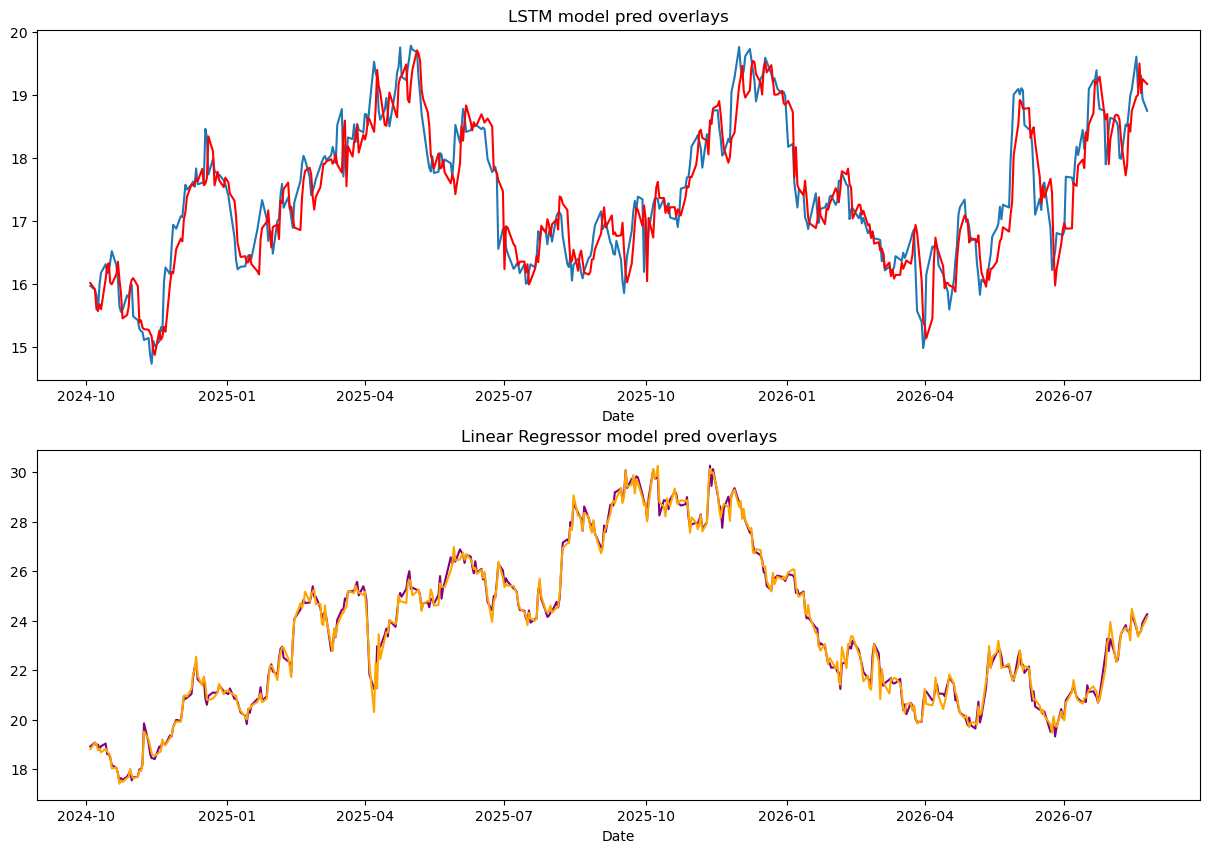

In [51]:
# plot overlays of both the linear regression model, with target values and predictions and the best lstm model config

fig, ax = plt.subplots(2,1, figsize=(15, 10))

sns.lineplot(x=data.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_true_lstm.reshape(y_test_true_lstm.shape[0]), ax=ax[0])
sns.lineplot(x=data.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_pred_lstm.reshape(y_test_pred_lstm.shape[0]), ax=ax[0], color='red')
ax[0].set_title('LSTM model pred overlays')

sns.lineplot(x=data.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_true.reshape(y_test_true.shape[0]), ax=ax[1], color='purple')
sns.lineplot(x=data.index[X_train.shape[0] + X_val.shape[0] :], y=y_test_pred.reshape(y_test_pred.shape[0]), ax=ax[1], color='orange')
ax[1].set_title('Linear Regressor model pred overlays')
plt.savefig('model_comparison.png')
plt.show()

In [149]:
# save the lstm model to the current directory
torch.save(best_model, "../models/lstm_non-stationary.pt")
print("Saved best checkpoint model to ../models/lstm_non-stationary.pt")

In [150]:
# save linear regressor model using pickle
with open('./linear_regressor_non-stationary.pkl','wb') as f:
    pickle.dump(lr,f)